# Financial Health Prediction Challenge
## Predicting SME Financial Well-being in Southern Africa

**Target**: Financial Health Index (FHI) — Low / Medium / High  
**Data**: 9 618 training samples, 2 405 test samples, 38 features  
**Countries**: Eswatini, Lesotho, Zimbabwe, Malawi

## 1. Imports & Setup

In [37]:
%pip install lightgbm catboost shap optuna --quiet

Note: you may need to restart the kernel to use updated packages.


In [38]:
import warnings, os, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              log_loss, f1_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR = "/home/conite/Documents/WORKSPACE/PROJECTS/Kaggle/Financial Health Prediction Challenge/data"
SEED     = 42
N_FOLDS  = 5
TARGET   = "Target"
TARGET_ORDER = ["Low", "Medium", "High"]          # ordinal order
TARGET_MAP   = {"Low": 0, "Medium": 1, "High": 2}
TARGET_IMAP  = {0: "Low", 1: "Medium", 2: "High"}

print("Environment ready.")


Environment ready.


## 2. Data Loading

In [39]:
train    = pd.read_csv(f"{DATA_DIR}/Train.csv")
test     = pd.read_csv(f"{DATA_DIR}/Test.csv")
var_def  = pd.read_csv(f"{DATA_DIR}/VariableDefinitions.csv")
sample   = pd.read_csv(f"{DATA_DIR}/SampleSubmission.csv")

print(f"Train : {train.shape}   Test : {test.shape}")
print(f"Sample submission columns : {list(sample.columns)}")
train.head(3)


Train : (9618, 39)   Test : (2405, 38)
Sample submission columns : ['ID', 'Target']


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,7000.0,14.0,Never had,Have now,Yes,Yes,Male,"Yes, sometimes",No,Never had,"Yes, always",Yes,Yes,No,Yes,Yes,Yes,Yes,Never had,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,NaN,15.0,Have now,Have now,NaN,Yes,Male,"Yes, sometimes",Yes,Never had,"Yes, always",No,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,"Yes, sometimes",Yes,Never had,No,Don?t know / doesn?t apply,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low


## 3. Data Overview

In [40]:
print("=== Variable Definitions ===")
var_def.style.set_properties(**{"text-align": "left"})


=== Variable Definitions ===


,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatini/Lesotho/Malawi/Zimbabwe)
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable business environment in the future
4,attitude_worried_shutdown,Owner attitude: Worried that the business will shut down
5,compliance_income_tax,Business complies with or acts in accordance with income tax regulations
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the kinds of losses the business suffers
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance payments
8,personal_income,Total monthly personal income of the owner before tax and other deductions
9,business_expenses,Approximate monthly or annual expenses of the business in local currency


In [41]:
print("=== Data Types ===")
print(train.dtypes.value_counts())
print()
numeric_cols = train.select_dtypes(include="number").columns.difference([TARGET]).tolist()
categ_cols   = [c for c in train.select_dtypes(include="object").columns
                if c not in ("ID", TARGET)]
print(f"Numeric features : {len(numeric_cols)} → {numeric_cols}")
print(f"Categorical features : {len(categ_cols)}")


=== Data Types ===
object     33
float64     6
Name: count, dtype: int64

Numeric features : 6 → ['business_age_months', 'business_age_years', 'business_expenses', 'business_turnover', 'owner_age', 'personal_income']
Categorical features : 31


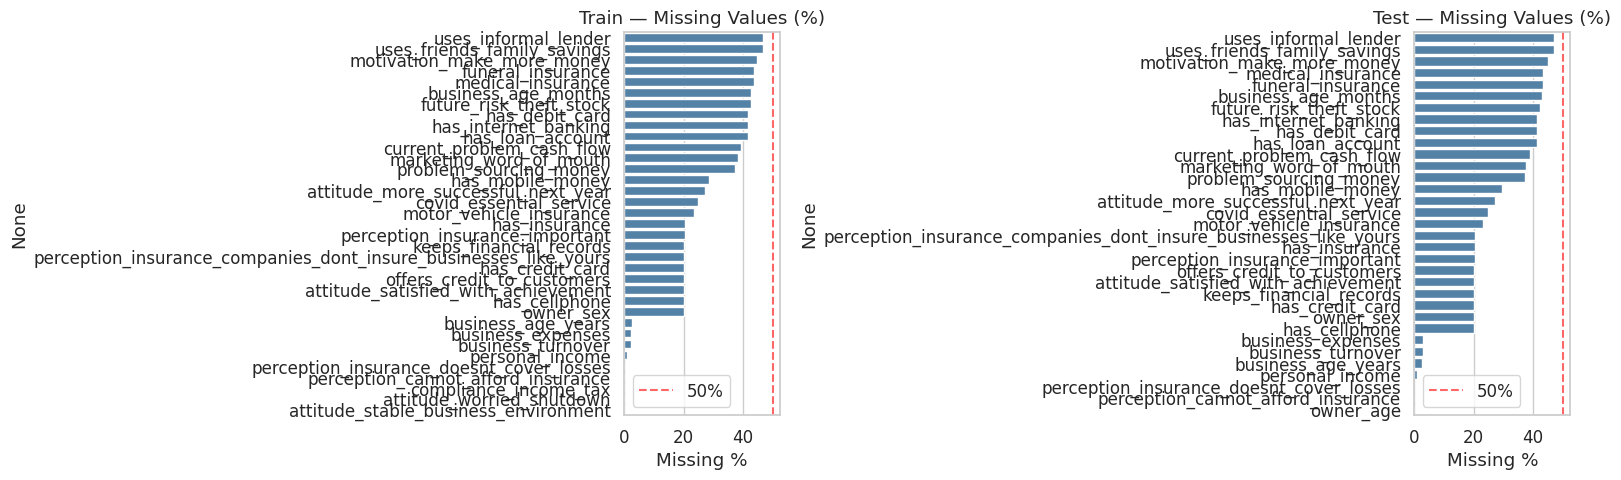


Train total missing cells : 81,276 (21.7% overall)


In [42]:
# Missing-value heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, name in zip(axes, [train, test], ["Train", "Test"]):
    miss_pct = df.isnull().mean().sort_values(ascending=False) * 100
    miss_pct = miss_pct[miss_pct > 0]
    sns.barplot(x=miss_pct.values, y=miss_pct.index, ax=ax, color="steelblue")
    ax.set_title(f"{name} — Missing Values (%)")
    ax.set_xlabel("Missing %")
    ax.axvline(50, color="red", linestyle="--", alpha=0.6, label="50%")
    ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTrain total missing cells : {train.isnull().sum().sum():,} "
      f"({train.isnull().mean().mean()*100:.1f}% overall)")


## 4. Target Analysis

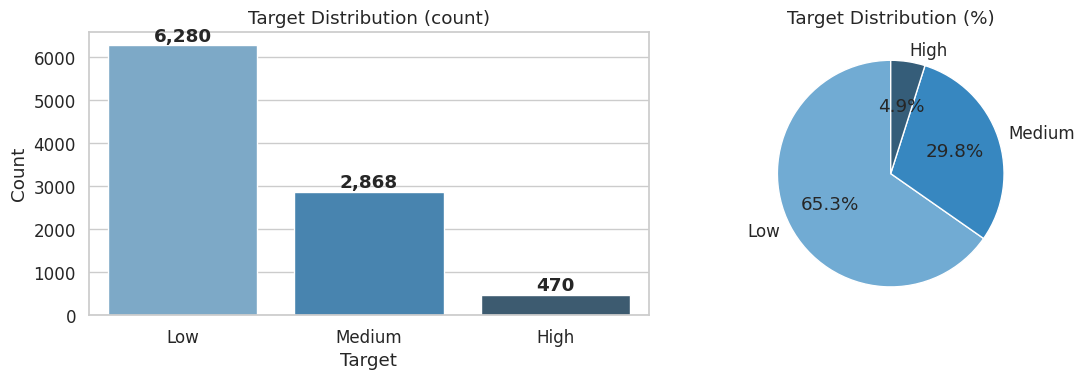

Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64

Class imbalance ratio (High vs Low): 13.4x


In [43]:
vc = train[TARGET].value_counts().reindex(TARGET_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
sns.barplot(x=vc.index, y=vc.values, palette="Blues_d", ax=axes[0])
axes[0].set_title("Target Distribution (count)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontweight="bold")

# Pie
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=sns.color_palette("Blues_d", 3), startangle=90)
axes[1].set_title("Target Distribution (%)")
plt.tight_layout(); plt.show()

print(vc)
print()
print("Class imbalance ratio (High vs Low):", f"{vc['Low']/vc['High']:.1f}x")


## 5. Exploratory Data Analysis

### 5.1 Numeric Features vs Target

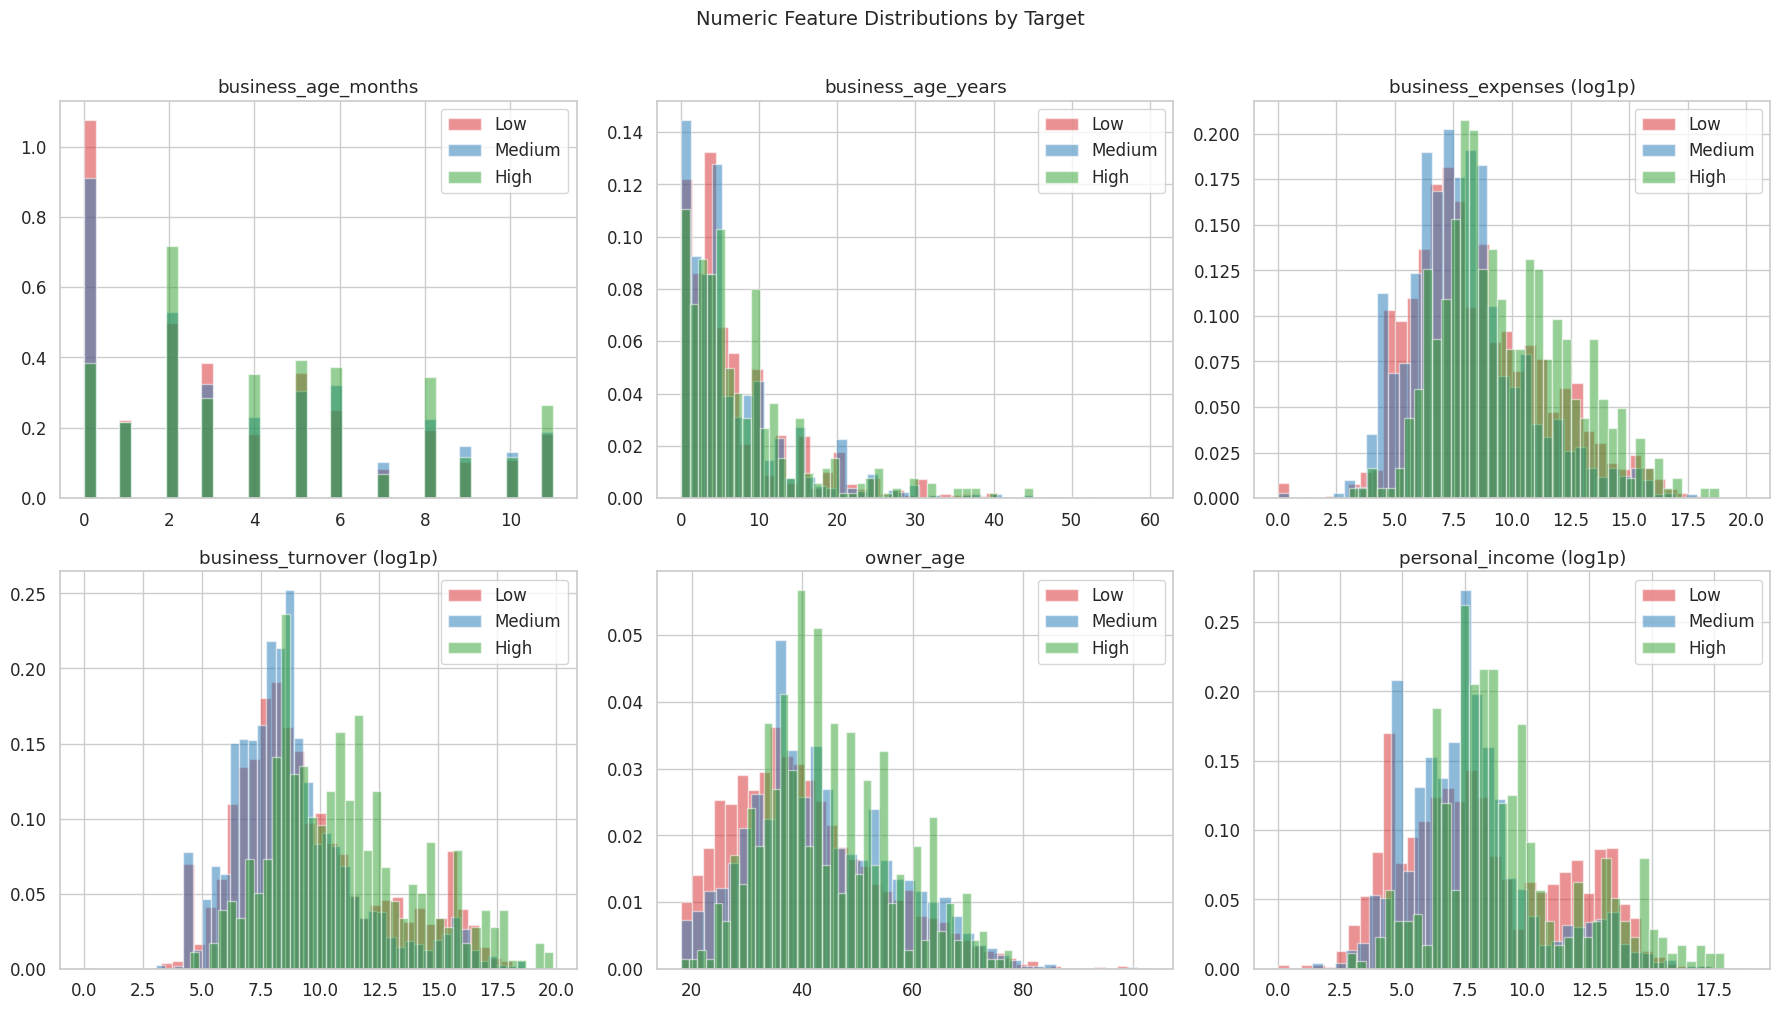

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in zip(TARGET_ORDER, ["#d62728", "#1f77b4", "#2ca02c"]):
        vals = train.loc[train[TARGET]==label, col].dropna()
        # log-transform for skewed financial figures
        if col in ("personal_income","business_expenses","business_turnover"):
            vals = np.log1p(vals)
        axes[i].hist(vals, bins=40, alpha=0.5, label=label, color=color, density=True)
    title = col + (" (log1p)" if col in ("personal_income","business_expenses","business_turnover") else "")
    axes[i].set_title(title)
    axes[i].legend()

plt.suptitle("Numeric Feature Distributions by Target", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


| Variable          | Séparation | Importance probable |
| ----------------- | ---------- | ------------------- |
| business_age      | Moyenne    | Bonne               |
| business_turnover | Bonne      | Forte               |
| business_expenses | Faible     | Moyenne             |
| owner_age         | Faible     | Faible              |
| personal_income   | Bonne      | Forte               |


**Conclusion:**

Les variables numériques montrent une séparation partielle entre les classes du Financial Health Index. Les entreprises classées “High” tendent à être plus anciennes, avec un chiffre d’affaires et un revenu personnel plus élevés. Cependant, les distributions présentent un fort chevauchement entre les classes, indiquant que les variables numériques seules ne suffisent pas à discriminer parfaitement les niveaux de santé financière. La modélisation devra donc exploiter des relations non linéaires et intégrer les variables catégorielles (accès au crédit, assurance, formalisation) pour capturer pleinement la structure du FHI.

### 5.2 Categorical Features vs Target

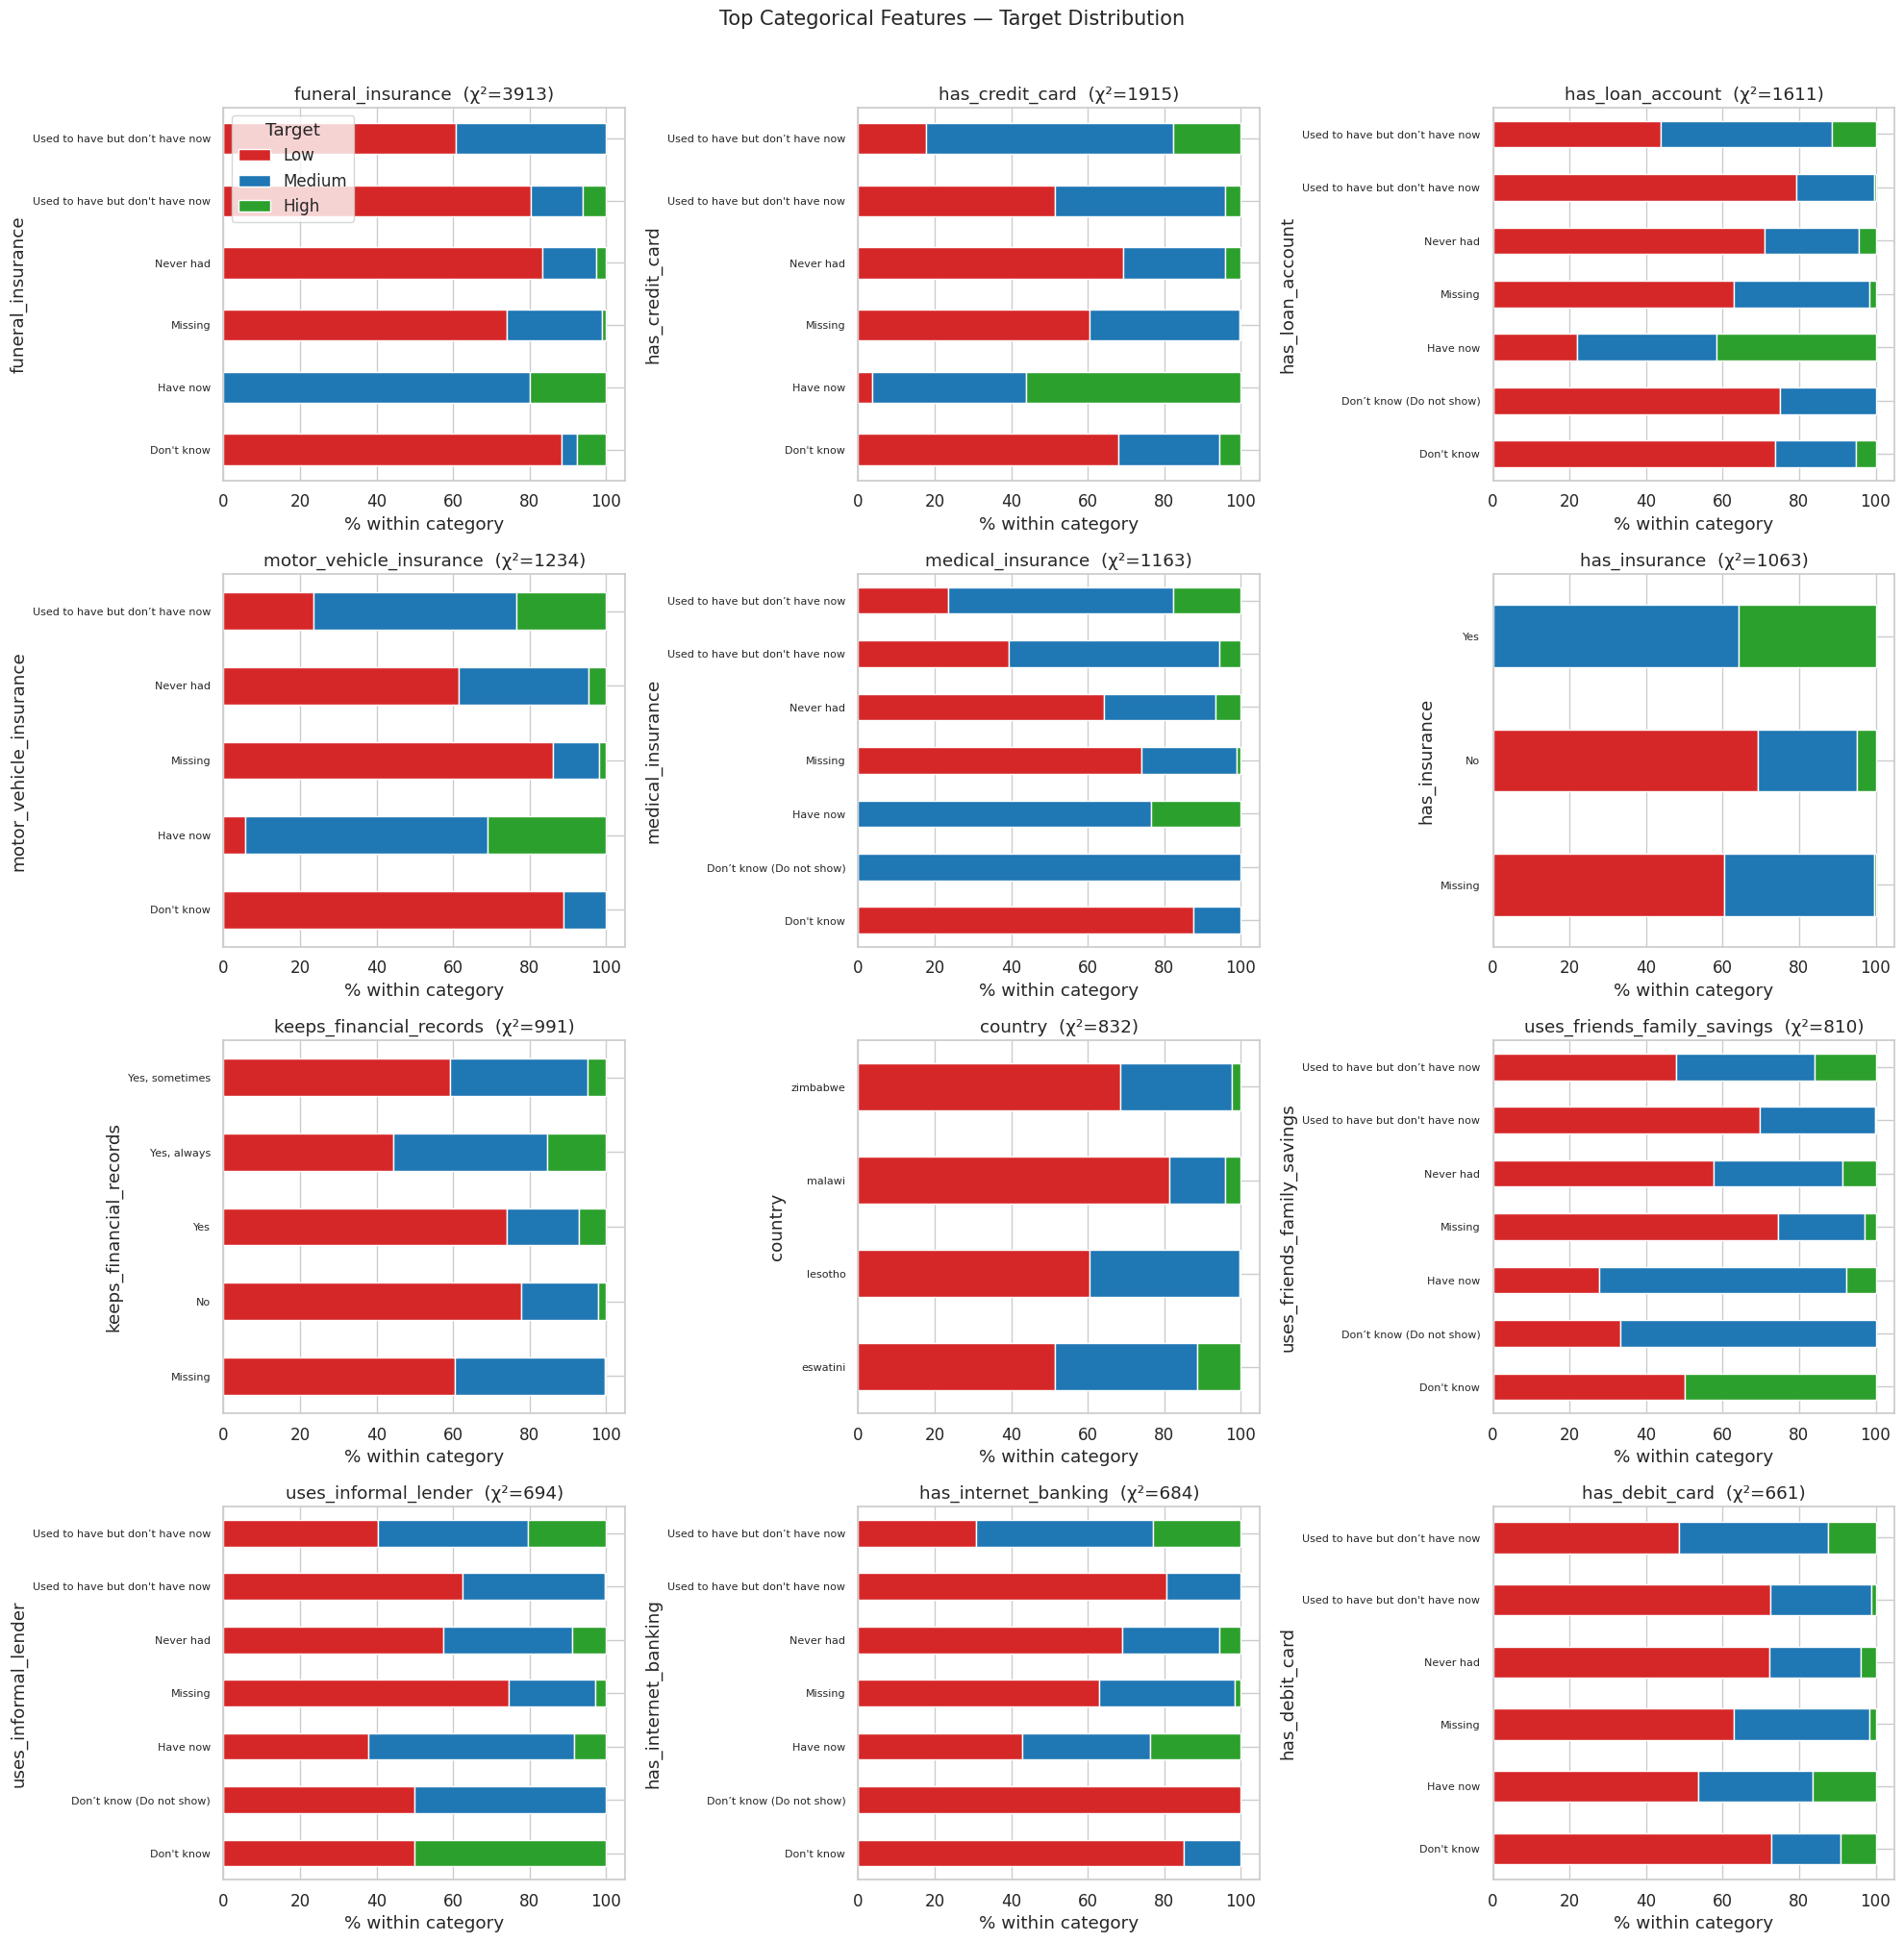

In [45]:
# Show top-10 most informative categorical features (by chi2 proxy: entropy variance)
from scipy.stats import chi2_contingency

chi2_scores = {}
for col in categ_cols:
    ct = pd.crosstab(train[col].fillna("Missing"), train[TARGET])
    chi2, p, _, _ = chi2_contingency(ct)
    chi2_scores[col] = chi2

top_cats = sorted(chi2_scores, key=chi2_scores.get, reverse=True)[:12]

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(top_cats):
    ct = pd.crosstab(train[col].fillna("Missing"), train[TARGET], normalize="index") * 100
    ct = ct.reindex(columns=TARGET_ORDER, fill_value=0)
    ct.plot(kind="barh", stacked=True, ax=axes[i],
            color=["#d62728","#1f77b4","#2ca02c"], legend=(i==0))
    axes[i].set_title(f"{col}  (χ²={chi2_scores[col]:.0f})")
    axes[i].set_xlabel("% within category")
    axes[i].tick_params(axis="y", labelsize=8)

plt.suptitle("Top Categorical Features — Target Distribution", fontsize=15, y=1.01)
plt.tight_layout(); plt.show()


Conclusion:

- Les variables liées à l’assurance (funeral, medical, motor, has_insurance) montrent la plus forte association avec le Financial Health Index (χ² très élevés), indiquant que la couverture assurantielle est un marqueur majeur de santé financière.

- L’accès au crédit formel (has_credit_card, has_loan_account, has_debt_card) et aux services bancaires numériques (has_internet_banking) est fortement corrélé à une meilleure santé financière (plus de Medium et High).

- Les entreprises tenant des registres financiers (keeps_financial_records) présentent une proportion plus élevée de Medium et High, ce qui souligne l’importance de la formalisation.

- Le recours aux prêteurs informels (uses_informal_lender) est davantage associé à la classe Low, suggérant une fragilité financière structurelle.

- Le pays (country) influence la distribution des classes, indiquant des différences structurelles entre contextes nationaux.

- Globalement, la santé financière est fortement liée à l’inclusion financière formelle, à la gestion structurée et à la capacité de gestion des risques.

### 5.3 Country Analysis

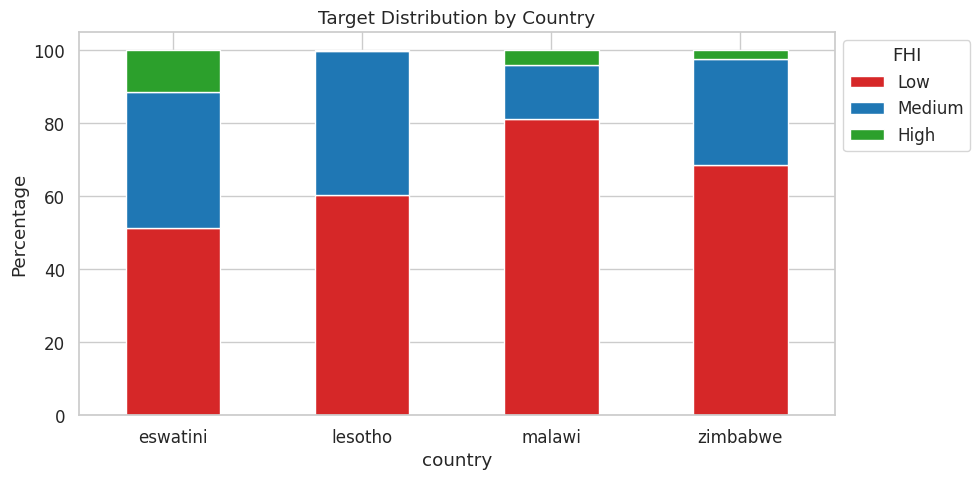

Target     Low  Medium  High
country                     
eswatini  51.4    37.1  11.5
lesotho   60.4    39.3   0.3
malawi    81.2    14.7   4.0
zimbabwe  68.6    29.1   2.3


In [46]:
country_target = pd.crosstab(train["country"], train[TARGET], normalize="index") * 100
country_target = country_target.reindex(columns=TARGET_ORDER)
country_target.plot(kind="bar", stacked=True, figsize=(10, 5),
                    color=["#d62728","#1f77b4","#2ca02c"])
plt.title("Target Distribution by Country")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="FHI", bbox_to_anchor=(1,1))
plt.tight_layout(); plt.show()
print(country_target.round(1))


## 6. Data Cleaning

In [47]:
def clean_text(x):
    """Normalise inconsistent encodings across survey responses."""
    if pd.isna(x):
        return x
    x = str(x).strip()
    # Smart-quotes / unicode apostrophes → straight apostrophe
    x = x.replace("\u2019","'").replace("\u2018","'").replace("?", "'")
    # Normalise "Don't know" variants
    x = re.sub(r"don.{0,2}t know.*", "Don't know", x, flags=re.IGNORECASE)
    x = re.sub(r"do not know.*", "Don't know", x, flags=re.IGNORECASE)
    # Normalise "Used to have" variants (extra spaces)
    x = re.sub(r"used to have.*", "Used to have", x, flags=re.IGNORECASE)
    return x.strip()

def clean_df(df):
    df = df.copy()
    for col in df.select_dtypes("object").columns:
        if col == "ID":
            continue
        df[col] = df[col].apply(clean_text)
    # Fix current_problem_cash_flow: '0' → 'No'
    if "current_problem_cash_flow" in df.columns:
        df["current_problem_cash_flow"] = df["current_problem_cash_flow"].replace("0", "No")
    # Clip numeric outliers at 99th percentile (train-derived)
    return df

train_clean = clean_df(train)
test_clean  = clean_df(test)

# Verify unique values after cleaning
print("After cleaning — unique values per categorical feature:")
for col in categ_cols[:8]:
    print(f"  {col}: {sorted(train_clean[col].dropna().unique())}")


After cleaning — unique values per categorical feature:
  country: ['eswatini', 'lesotho', 'malawi', 'zimbabwe']
  attitude_stable_business_environment: ["Don't know", 'No', 'Yes']
  attitude_worried_shutdown: ["Don't know", 'No', 'Yes']
  compliance_income_tax: ["Don't know", 'No', 'Refused', 'Yes']
  perception_insurance_doesnt_cover_losses: ["Don't know", 'No', 'Yes']
  perception_cannot_afford_insurance: ["Don't know", 'No', 'Yes']
  motor_vehicle_insurance: ["Don't know", 'Have now', 'Never had', 'Used to have']
  has_mobile_money: ["Don't know", 'Have now', 'Never had', 'Used to have']


In [48]:
# Clip financial outliers at 99th percentile (fit on train only)
fin_cols = ["personal_income", "business_expenses", "business_turnover"]
for col in fin_cols:
    cap = train_clean[col].quantile(0.99)
    train_clean[col] = train_clean[col].clip(upper=cap)
    test_clean[col]  = test_clean[col].clip(upper=cap)

print("Financial columns capped at 99th percentile (train).")
print(train_clean[fin_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).T[["mean", "50%", "99%", "max"]])


Financial columns capped at 99th percentile (train).
                            mean     50%         99%         max
personal_income    147030.004391  2000.0   3128464.0   3129200.0
business_expenses  254896.018745  3000.0   8002304.0   8019200.0
business_turnover  990154.513401  6000.0  24990050.0  24995000.0


## 7. Feature Engineering

In [49]:
def engineer_features(df):
    df = df.copy()

    # 1. Unified business age (years + months/12)
    df["business_age_total"] = (
        df["business_age_years"].fillna(0) +
        df["business_age_months"].fillna(0) / 12
    )

    # 2. Financial ratios (log-scale)
    eps = 1.0
    df["log_income"]    = np.log1p(df["personal_income"].clip(lower=0))
    df["log_expenses"]  = np.log1p(df["business_expenses"].clip(lower=0))
    df["log_turnover"]  = np.log1p(df["business_turnover"].clip(lower=0))

    # Profit proxy & margin
    df["profit_proxy"]  = df["business_turnover"].fillna(0) - df["business_expenses"].fillna(0)
    df["log_profit"]    = np.log1p(df["profit_proxy"].clip(lower=0))
    df["expense_ratio"] = df["business_expenses"] / (df["business_turnover"] + eps)
    df["income_turnover_ratio"] = df["personal_income"] / (df["business_turnover"] + eps)

    # 3. Financial product access score
    # "Have now" = 2, "Used to have" = 1, "Never had" = 0, "Don't know" = 0
    product_map = {"Have now": 2, "Used to have": 1, "Never had": 0, "Don't know": 0}
    product_cols = ["motor_vehicle_insurance", "has_mobile_money", "has_credit_card",
                    "has_loan_account", "has_internet_banking", "has_debit_card",
                    "medical_insurance", "funeral_insurance", "uses_friends_family_savings",
                    "uses_informal_lender"]
    for col in product_cols:
        if col in df.columns:
            df[f"{col}_score"] = df[col].map(product_map).fillna(0)
    score_cols = [f"{c}_score" for c in product_cols if c in df.columns]
    df["financial_access_score"] = df[score_cols].sum(axis=1)

    # 4. Binary flags: is owner male / female
    df["is_male"] = (df["owner_sex"] == "Male").astype(int)

    # 5. Missing-value count (informative missingness)
    df["n_missing"] = df.isnull().sum(axis=1)

    # 6. Positive attitude composite
    pos_att = ["attitude_stable_business_environment", "attitude_more_successful_next_year",
               "attitude_satisfied_with_achievement"]
    for col in pos_att:
        df[f"{col}_bin"] = (df[col] == "Yes").astype(int)
    df["positive_attitude"] = df[[f"{c}_bin" for c in pos_att]].sum(axis=1)

    # 7. Insurance awareness score
    ins_cols = ["perception_insurance_important", "has_insurance"]
    df["insurance_engaged"] = (
        (df["perception_insurance_important"] == "Yes").astype(int) +
        (df["has_insurance"] == "Yes").astype(int)
    )

    # 8. Formal-finance flag
    df["uses_formal_finance"] = (
        (df["has_credit_card"].isin(["Have now"])).astype(int) +
        (df["has_loan_account"].isin(["Have now"])).astype(int) +
        (df["has_internet_banking"].isin(["Have now"])).astype(int) +
        (df["has_debit_card"].isin(["Have now"])).astype(int)
    )

    return df

train_fe = engineer_features(train_clean)
test_fe  = engineer_features(test_clean)

new_feats = [c for c in train_fe.columns if c not in train_clean.columns]
print(f"New engineered features ({len(new_feats)}): {new_feats}")


New engineered features (27): ['business_age_total', 'log_income', 'log_expenses', 'log_turnover', 'profit_proxy', 'log_profit', 'expense_ratio', 'income_turnover_ratio', 'motor_vehicle_insurance_score', 'has_mobile_money_score', 'has_credit_card_score', 'has_loan_account_score', 'has_internet_banking_score', 'has_debit_card_score', 'medical_insurance_score', 'funeral_insurance_score', 'uses_friends_family_savings_score', 'uses_informal_lender_score', 'financial_access_score', 'is_male', 'n_missing', 'attitude_stable_business_environment_bin', 'attitude_more_successful_next_year_bin', 'attitude_satisfied_with_achievement_bin', 'positive_attitude', 'insurance_engaged', 'uses_formal_finance']


## 8. Encoding & Preprocessing Pipeline

In [50]:
# Define ordinal mappings for survey-style categories
HAVE_ORDER  = ["Never had", "Used to have", "Don't know", "Have now"]
YES_NO_DK   = ["No", "Don't know", "Yes"]
YES_NO      = ["No", "Yes"]
AGREE_ORDER = ["No", "Don't know or N/A", "Yes"]
AGREE2      = ["No", "Don't know", "Yes"]
OFFER_ORDER = ["No", "Yes, sometimes", "Yes, always"]
KEEP_ORDER  = ["No", "Yes, sometimes", "Yes, always", "Yes"]
COMPLY_MAP  = ["No", "Don't know", "Refused", "Yes"]

ordinal_spec = {
    "attitude_stable_business_environment"                      : AGREE_ORDER,
    "attitude_worried_shutdown"                                 : AGREE_ORDER,
    "compliance_income_tax"                                     : COMPLY_MAP,
    "perception_insurance_doesnt_cover_losses"                  : YES_NO_DK,
    "perception_cannot_afford_insurance"                        : YES_NO_DK,
    "motor_vehicle_insurance"                                   : HAVE_ORDER,
    "has_mobile_money"                                          : HAVE_ORDER,
    "current_problem_cash_flow"                                 : YES_NO,
    "has_cellphone"                                             : YES_NO,
    "offers_credit_to_customers"                                : OFFER_ORDER,
    "attitude_satisfied_with_achievement"                       : AGREE2,
    "has_credit_card"                                           : HAVE_ORDER,
    "keeps_financial_records"                                   : KEEP_ORDER,
    "perception_insurance_companies_dont_insure_businesses_like_yours": YES_NO_DK,
    "perception_insurance_important"                            : YES_NO_DK,
    "has_insurance"                                             : YES_NO,
    "covid_essential_service"                                   : YES_NO_DK,
    "attitude_more_successful_next_year"                        : AGREE2,
    "problem_sourcing_money"                                    : YES_NO,
    "marketing_word_of_mouth"                                   : YES_NO,
    "has_loan_account"                                          : HAVE_ORDER,
    "has_internet_banking"                                      : HAVE_ORDER,
    "has_debit_card"                                            : HAVE_ORDER,
    "future_risk_theft_stock"                                   : YES_NO,
    "medical_insurance"                                         : HAVE_ORDER,
    "funeral_insurance"                                         : HAVE_ORDER,
    "motivation_make_more_money"                                : YES_NO,
    "uses_friends_family_savings"                               : HAVE_ORDER,
    "uses_informal_lender"                                      : HAVE_ORDER,
    "owner_sex"                                                 : ["Female", "Male"],
}

def encode_df(df, ordinal_spec):
    """Ordinal-encode survey features; label-encode country."""
    df = df.copy()
    for col, order in ordinal_spec.items():
        if col not in df.columns:
            continue
        cat = pd.Categorical(df[col], categories=order, ordered=True)
        df[col] = cat.codes.astype(float)      # -1 → NaN will stay as -1 for tree models
        df[col] = df[col].replace(-1, np.nan)

    # Country → label encode
    le_country = LabelEncoder()
    df["country"] = le_country.fit_transform(df["country"].fillna("unknown"))
    return df

train_enc = encode_df(train_fe, ordinal_spec)
test_enc  = encode_df(test_fe,  ordinal_spec)

# Prepare X, y
EXCLUDE_COLS = {"ID", TARGET} | set(
    [c for c in train_enc.columns if c.endswith("_bin")]  # redundant with composites
)
feature_cols = [c for c in train_enc.columns if c not in EXCLUDE_COLS]

X = train_enc[feature_cols].copy()
y = train_enc[TARGET].map(TARGET_MAP)
X_test = test_enc[feature_cols].copy()

print(f"Feature matrix: {X.shape}  |  Classes: {y.value_counts().to_dict()}")
print(f"Features ({len(feature_cols)}):\n", feature_cols)


Feature matrix: (9618, 61)  |  Classes: {0: 6280, 1: 2868, 2: 470}
Features (61):
 ['country', 'owner_age', 'attitude_stable_business_environment', 'attitude_worried_shutdown', 'compliance_income_tax', 'perception_insurance_doesnt_cover_losses', 'perception_cannot_afford_insurance', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'motor_vehicle_insurance', 'has_mobile_money', 'current_problem_cash_flow', 'has_cellphone', 'owner_sex', 'offers_credit_to_customers', 'attitude_satisfied_with_achievement', 'has_credit_card', 'keeps_financial_records', 'perception_insurance_companies_dont_insure_businesses_like_yours', 'perception_insurance_important', 'has_insurance', 'covid_essential_service', 'attitude_more_successful_next_year', 'problem_sourcing_money', 'marketing_word_of_mouth', 'has_loan_account', 'has_internet_banking', 'has_debit_card', 'future_risk_theft_stock', 'business_age_months', 'medical_insurance', 'funeral_insurance', 'motivation_make_more

## 9. Validation Strategy

In [51]:
# StratifiedKFold — preserves class proportions across folds
# Critical given High-class minority (4.9%)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Metric: macro log-loss (penalises confident wrong predictions)
# Also track macro-F1 for interpretability
def evaluate_model(model, X, y, cv, label=""):
    scores_ll  = []
    scores_f1  = []
    scores_f1h = []
    for fold, (tr, va) in enumerate(cv.split(X, y)):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        model.fit(Xtr, ytr)
        proba = model.predict_proba(Xva)
        pred  = model.predict(Xva)
        scores_ll.append( log_loss(yva, proba))
        scores_f1.append( f1_score(yva, pred, average="macro"))
        scores_f1h.append(f1_score(yva, pred, average=None)[2])  # High class

    print(f"{'Model':<30} LogLoss={np.mean(scores_ll):.4f}±{np.std(scores_ll):.4f} "
          f"MacroF1={np.mean(scores_f1):.4f}  HighF1={np.mean(scores_f1h):.4f}")
    return scores_ll, scores_f1

print("Validation framework: 5-Fold Stratified CV")
print(f"Metric: Log-Loss (primary), Macro-F1 (secondary)")
print(f"Fold sizes (approx): {len(X)//N_FOLDS} validation samples each")


Validation framework: 5-Fold Stratified CV
Metric: Log-Loss (primary), Macro-F1 (secondary)
Fold sizes (approx): 1923 validation samples each


## 10. Baseline Model

In [52]:
# 10a. Dummy baseline
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
print("--- Dummy (stratified) ---")
evaluate_model(dummy, X, y, skf)

# 10b. Logistic Regression baseline (median imputation first)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lr_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced",
                       random_state=SEED, C=0.1)
)
print("\n--- Logistic Regression (balanced) ---")
evaluate_model(lr_pipe, X, y, skf)


--- Dummy (stratified) ---
Model                          LogLoss=17.3548±0.4215 MacroF1=0.3284  HighF1=0.0319

--- Logistic Regression (balanced) ---
Model                          LogLoss=0.4486±0.0173 MacroF1=0.7166  HighF1=0.5755


([0.47420786651081176,
  0.44483440112363126,
  0.455248721643378,
  0.44789172030869945,
  0.42069541951596945],
 [0.7016844733455762,
  0.7193367799765243,
  0.7061271134663448,
  0.7113074000026129,
  0.7447207327432924])

**Conclusion:**

Le modèle Dummy confirme le fort déséquilibre du dataset, avec une performance très faible sur la classe High (HighF1 ≈ 0.03), ce qui montre qu’un modèle naïf ne parvient pas à capturer la structure du problème. En revanche, la Logistic Regression avec pondération des classes (balanced) obtient des performances solides (LogLoss ≈ 0.45, MacroF1 ≈ 0.72, HighF1 ≈ 0.58), avec une faible variance entre les folds, indiquant une bonne stabilité et une séparation déjà bien structurée des classes. Cela valide la pertinence du feature engineering et confirme que les variables construites capturent efficacement les dimensions du Financial Health Index.

Recommandations:

- Utiliser cette Logistic Regression comme baseline solide.
- Tester un modèle de boosting (LightGBM ou CatBoost) pour capturer d’éventuelles relations non linéaires et viser un gain supplémentaire en MacroF1.
- Surveiller spécifiquement le HighF1, étant donné le fort déséquilibre.
- Ajuster éventuellement les seuils de décision (threshold tuning) si la métrique cible est le MacroF1.
- Vérifier la calibration des probabilités si la métrique officielle est le LogLoss.
- Analyser l’importance des variables afin d’identifier les features les plus structurantes et éliminer les redondances.

## 11. Advanced Models

In [53]:
# Compute class weights for imbalance
from sklearn.utils.class_weight import compute_sample_weight

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=30,
)

# Wrap XGB to support early stopping in CV
from copy import deepcopy

def evaluate_xgb(X, y, cv):
    scores_ll, scores_f1, scores_f1h = [], [], []
    for tr, va in cv.split(X, y):
        Xtr, Xva = X.iloc[tr].values, X.iloc[va].values
        ytr, yva = y.iloc[tr].values, y.iloc[va].values
        m = deepcopy(xgb_model)
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
        proba = m.predict_proba(Xva)
        pred  = m.predict(Xva)
        scores_ll.append( log_loss(yva, proba))
        scores_f1.append( f1_score(yva, pred, average="macro"))
        scores_f1h.append(f1_score(yva, pred, average=None)[2])
    print(f"{'XGBoost':<30} LogLoss={np.mean(scores_ll):.4f}±{np.std(scores_ll):.4f} "
          f"MacroF1={np.mean(scores_f1):.4f}  HighF1={np.mean(scores_f1h):.4f}")
    return scores_ll, scores_f1

print("--- XGBoost ---")
xgb_ll, xgb_f1 = evaluate_xgb(X, y, skf)


--- XGBoost ---


sh: 1: nvidia-smi: not found


XGBoost                        LogLoss=0.3052±0.0194 MacroF1=0.8116  HighF1=0.7261


In [55]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    objective="multiclass",
    num_class=3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

def evaluate_lgb(X, y, cv):
    scores_ll, scores_f1, scores_f1h = [], [], []
    for tr, va in cv.split(X, y):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        m = deepcopy(lgb_model)
        m.fit(Xtr, ytr,
              eval_set=[(Xva, yva)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(-1)])
        proba = m.predict_proba(Xva)
        pred  = m.predict(Xva)
        scores_ll.append( log_loss(yva, proba))
        scores_f1.append( f1_score(yva, pred, average="macro"))
        scores_f1h.append(f1_score(yva, pred, average=None)[2])
    print(f"{'LightGBM':<30} LogLoss={np.mean(scores_ll):.4f}±{np.std(scores_ll):.4f} "
          f"MacroF1={np.mean(scores_f1):.4f}  HighF1={np.mean(scores_f1h):.4f}")
    return scores_ll, scores_f1

print("--- LightGBM ---")
lgb_ll, lgb_f1 = evaluate_lgb(X, y, skf)


--- LightGBM ---
LightGBM                       LogLoss=0.3300±0.0182 MacroF1=0.7961  HighF1=0.7072


In [54]:
# ── CatBoost ──────────────────────────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    class_weights=[1.0, 2.2, 13.4],   # inverse of class frequencies
    random_seed=SEED,
    verbose=False,
    early_stopping_rounds=30,
)

def evaluate_cat(X, y, cv):
    scores_ll, scores_f1, scores_f1h = [], [], []
    for tr, va in cv.split(X, y):
        Xtr, Xva = X.iloc[tr], X.iloc[va]
        ytr, yva = y.iloc[tr], y.iloc[va]
        m = deepcopy(cat_model)
        m.fit(Xtr, ytr, eval_set=(Xva, yva), verbose=False)
        proba = m.predict_proba(Xva)
        pred  = m.predict(Xva).flatten()
        scores_ll.append( log_loss(yva, proba))
        scores_f1.append( f1_score(yva, pred, average="macro"))
        scores_f1h.append(f1_score(yva, pred, average=None)[2])
    print(f"{'CatBoost':<30} LogLoss={np.mean(scores_ll):.4f}±{np.std(scores_ll):.4f} "
          f"MacroF1={np.mean(scores_f1):.4f}  HighF1={np.mean(scores_f1h):.4f}")
    return scores_ll, scores_f1

print("--- CatBoost ---")
cat_ll, cat_f1 = evaluate_cat(X, y, skf)


--- CatBoost ---
CatBoost                       LogLoss=0.3738±0.0165 MacroF1=0.7675  HighF1=0.6669


## 12. Hyperparameter Tuning

In [56]:
# Tune LightGBM with Optuna (best baseline so far)
def objective_lgb(trial):
    params = {
        "n_estimators"      : trial.suggest_int("n_estimators", 300, 1000),
        "max_depth"         : trial.suggest_int("max_depth", 4, 8),
        "num_leaves"        : trial.suggest_int("num_leaves", 31, 127),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample"         : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree"  : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples" : trial.suggest_int("min_child_samples", 10, 50),
        "reg_alpha"         : trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda"        : trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective"         : "multiclass",
        "num_class"         : 3,
        "class_weight"      : "balanced",
        "random_state"      : SEED,
        "n_jobs"            : -1,
        "verbose"           : -1,
    }
    model = lgb.LGBMClassifier(**params)
    losses = []
    for tr, va in skf.split(X, y):
        model.fit(X.iloc[tr], y.iloc[tr],
                  eval_set=[(X.iloc[va], y.iloc[va])],
                  callbacks=[lgb.early_stopping(20, verbose=False),
                             lgb.log_evaluation(-1)])
        proba = model.predict_proba(X.iloc[va])
        losses.append(log_loss(y.iloc[va], proba))
    return np.mean(losses)

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\nBest log-loss : {study.best_value:.4f}")
print(f"Best params   : {study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]


Best log-loss : 0.3215
Best params   : {'n_estimators': 480, 'max_depth': 8, 'num_leaves': 121, 'learning_rate': 0.028041454756424472, 'subsample': 0.7537419480338071, 'colsample_bytree': 0.6621416682478823, 'min_child_samples': 13, 'reg_alpha': 0.38110749352041584, 'reg_lambda': 0.17330647239355554}


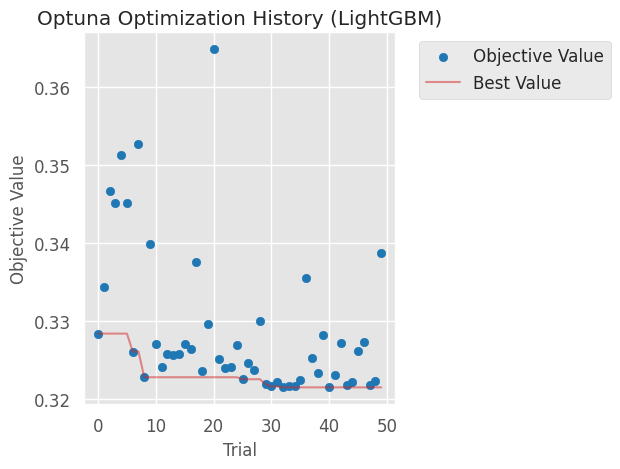

In [57]:
# Plot optimization history
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History (LightGBM)")
plt.tight_layout(); plt.show()


In [61]:
# Retrain best LGB with tuned params
best_params = study.best_params
best_params.update({"objective":"multiclass","num_class":3,"class_weight":"balanced",
                    "random_state":SEED,"n_jobs":-1,"verbose":-1})

lgb_tuned = lgb.LGBMClassifier(**best_params)
print("--- LightGBM (tuned) ---")
lgb_tuned_ll, lgb_tuned_f1 = evaluate_lgb(X, y, skf)


--- LightGBM (tuned) ---
LightGBM                       LogLoss=0.3300±0.0182 MacroF1=0.7961  HighF1=0.7072


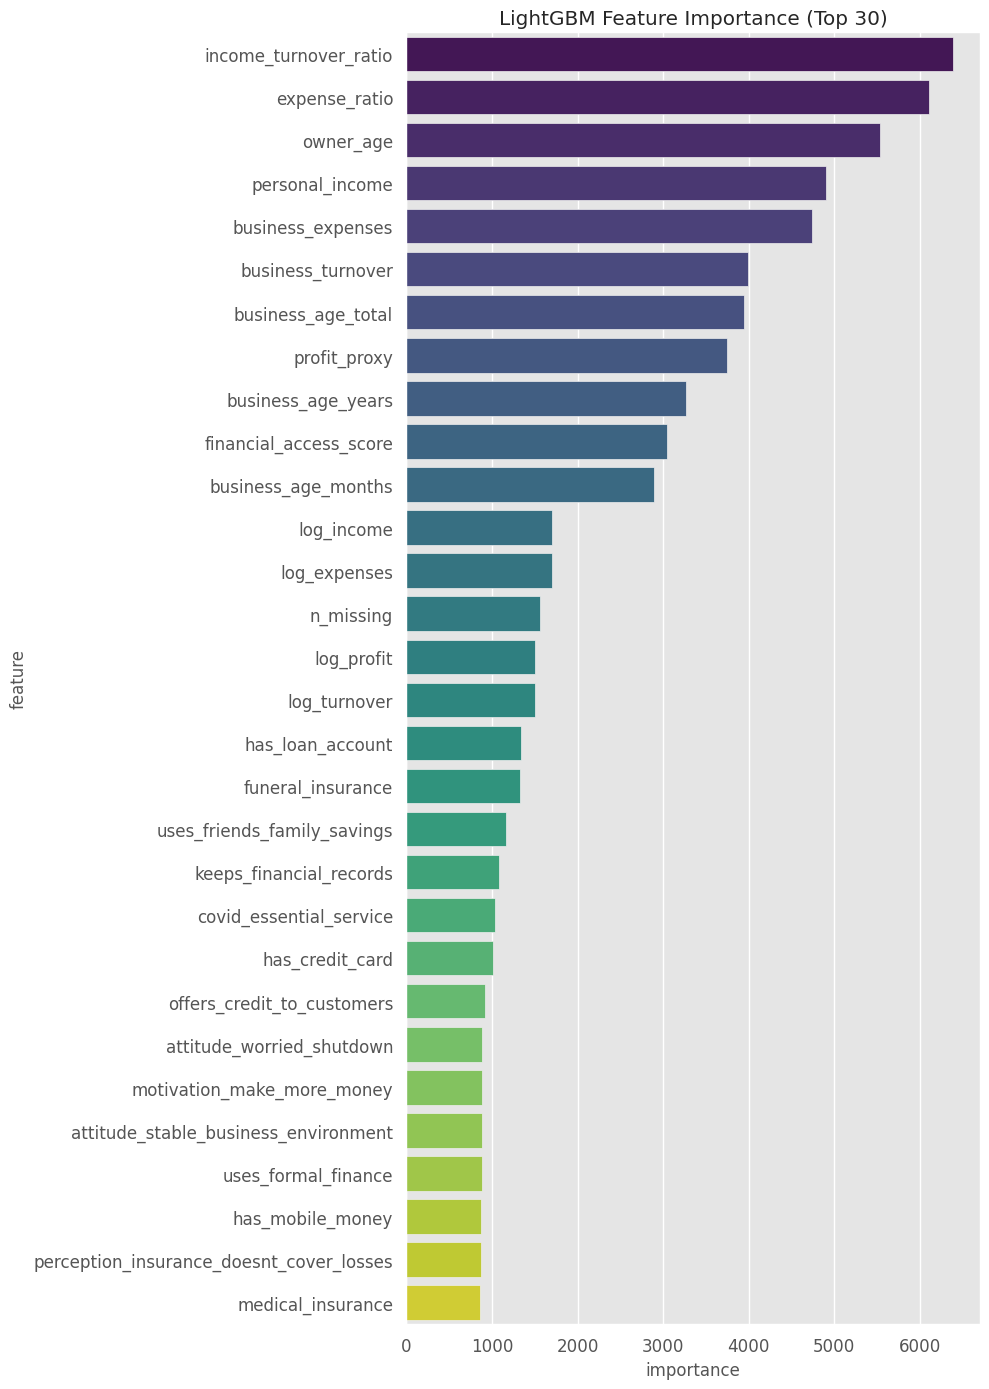

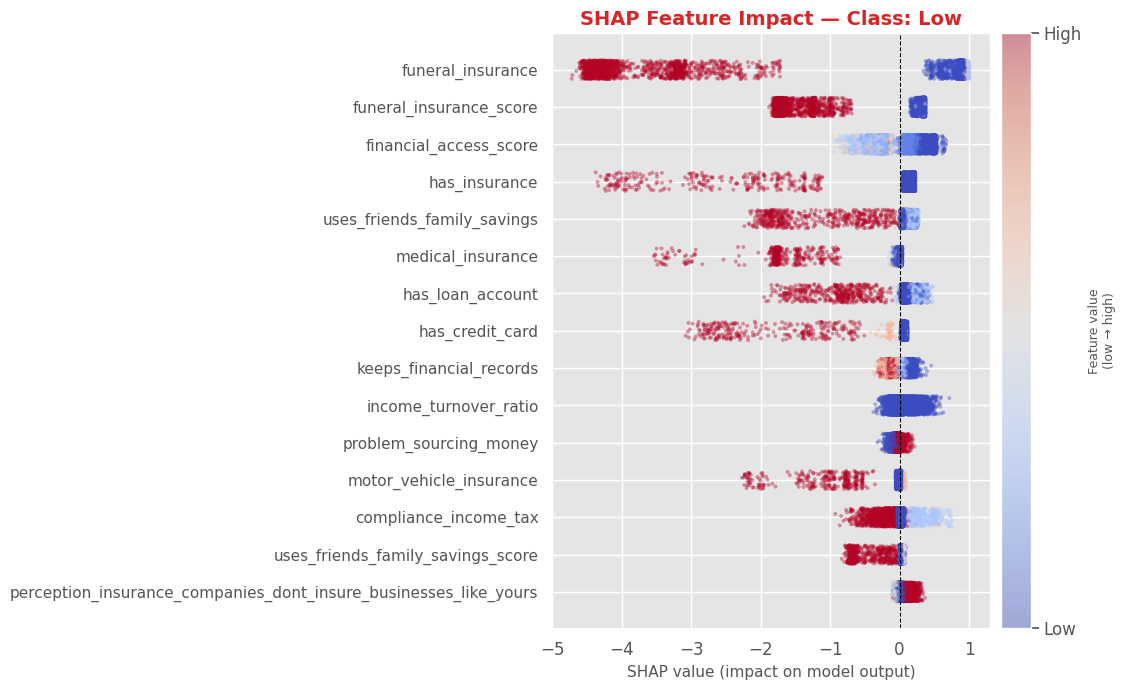

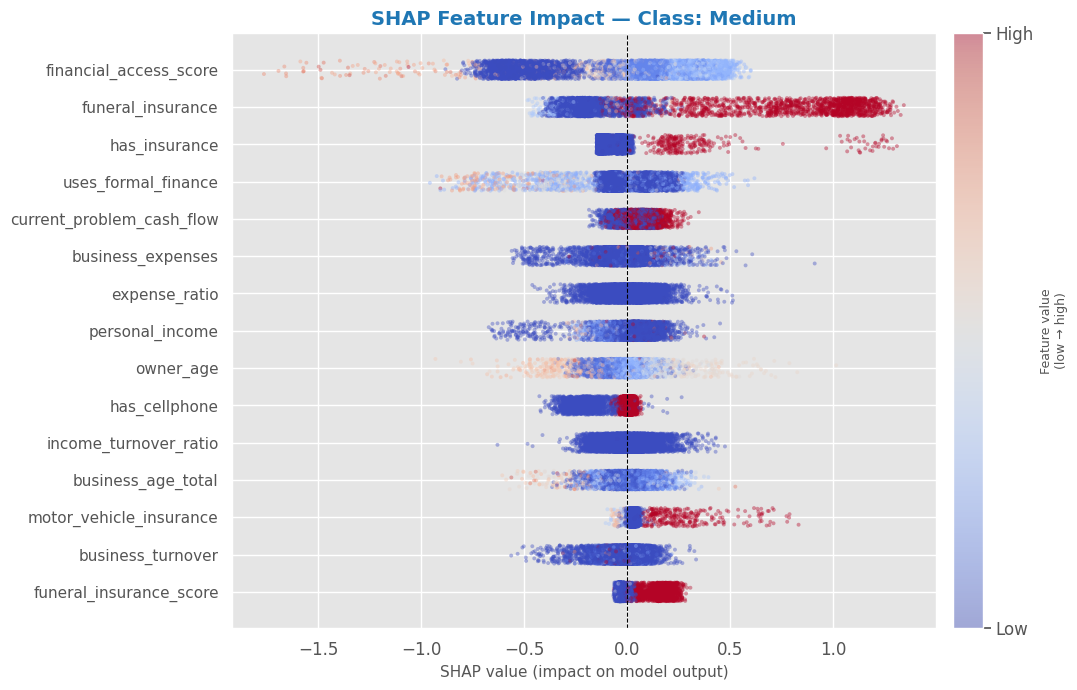

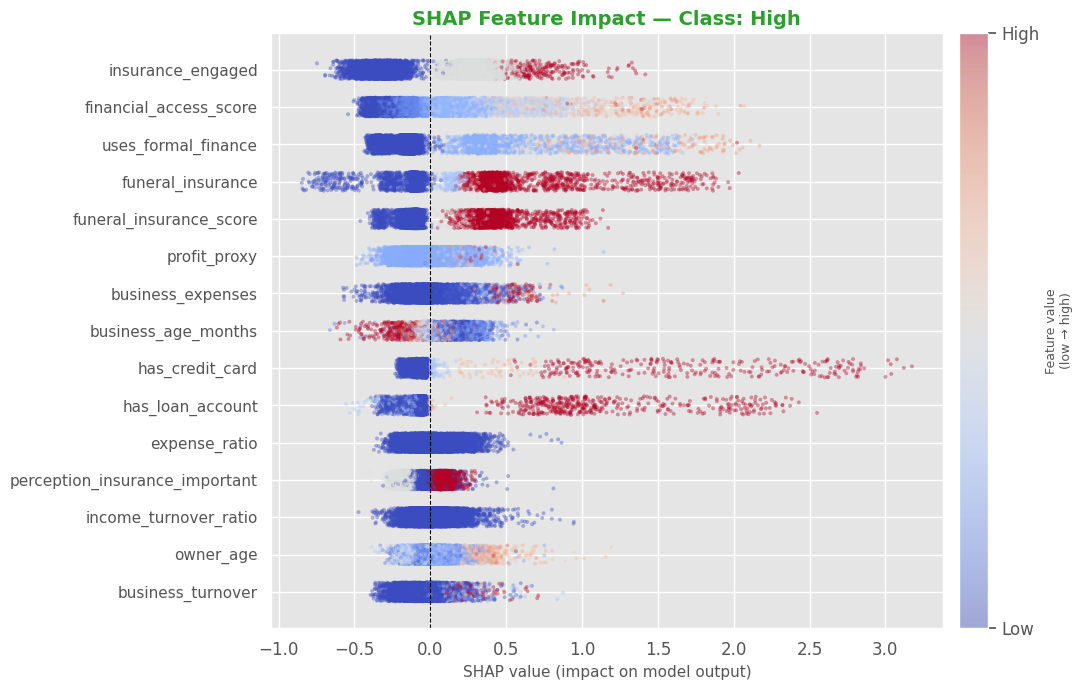

In [64]:
# ── Train on full data ────────────────────────────────────────────────────────
_params = best_params if "best_params" in dir() else {
    "n_estimators": 500, "max_depth": 6, "num_leaves": 63,
    "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8,
    "min_child_samples": 20, "objective": "multiclass", "num_class": 3,
    "class_weight": "balanced", "random_state": SEED, "n_jobs": -1, "verbose": -1,
}
lgb_final_for_shap = lgb.LGBMClassifier(**_params)
lgb_final_for_shap.fit(X, y, callbacks=[lgb.log_evaluation(-1)])

# ── Built-in feature importance ───────────────────────────────────────────────
fi = pd.DataFrame({
    "feature"    : feature_cols,
    "importance" : lgb_final_for_shap.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 14))
sns.barplot(data=fi.head(30), x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("LightGBM Feature Importance (Top 30)")
plt.tight_layout(); plt.show()

# ── SHAP ──────────────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(lgb_final_for_shap)
shap_values = explainer.shap_values(X)

# Handle both SHAP API versions:
# - Old (list): shap_values[i]      → (n_samples, n_features)
# - New (3D):   shap_values[:,:,i]  → (n_samples, n_features)
def get_shap_for_class(sv, i):
    return sv[i] if isinstance(sv, list) else sv[:, :, i]

# One large figure per class — full width, no overlap
class_names  = ["Low", "Medium", "High"]
class_colors = ["#d62728", "#1f77b4", "#2ca02c"]
N_DISPLAY    = 15

for i, (cls, color) in enumerate(zip(class_names, class_colors)):
    sv_cls = get_shap_for_class(shap_values, i)

    # Rank features by mean |SHAP| for this class
    mean_abs = np.abs(sv_cls).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:N_DISPLAY]
    top_idx  = top_idx[::-1]                          # bottom→top for readability

    top_sv   = sv_cls[:, top_idx]
    top_feat = X.iloc[:, top_idx]
    top_names = [feature_cols[j] for j in top_idx]

    fig, ax = plt.subplots(figsize=(11, 7))

    # Scatter: colour = feature value (normalised per feature), x = SHAP value
    for row_i, (fname, col_shap, col_feat) in enumerate(
            zip(top_names, top_sv.T, top_feat.T.values)):
        feat_vals = col_feat.astype(float)
        feat_norm = (feat_vals - np.nanmin(feat_vals)) / (
            np.nanmax(feat_vals) - np.nanmin(feat_vals) + 1e-9)

        # jitter y for beeswarm effect
        rng = np.random.default_rng(42 + row_i)
        jitter = rng.uniform(-0.25, 0.25, size=len(col_shap))

        sc = ax.scatter(col_shap, row_i + jitter,
                        c=feat_norm, cmap="coolwarm",
                        alpha=0.4, s=8, linewidths=0, vmin=0, vmax=1)

    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names, fontsize=11)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    ax.set_title(f"SHAP Feature Impact — Class: {cls}", fontsize=14, fontweight="bold",
                 color=color)

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("Feature value\n(low → high)", fontsize=9)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Low", "High"])

    plt.tight_layout()
    plt.show()


**Conclusion:**

L’analyse SHAP montre que le modèle distingue clairement les profils financiers selon trois dimensions majeures : inclusion financière, couverture assurantielle et performance économique. Les entreprises classées “Low” se caractérisent par un faible accès aux services financiers formels et une absence d’assurance, tandis que les entreprises “High” présentent une forte formalisation (cartes, prêts, internet banking), une meilleure rentabilité et une gestion active du risque. La classe “Medium” représente un état intermédiaire de transition. Les résultats SHAP confirment ainsi que le modèle capture de manière cohérente et économiquement interprétable la structure du Financial Health Index.

## 14. Error Analysis

In [67]:
# OOF predictions for error analysis
oof_preds  = np.zeros((len(X), 3))
oof_labels = np.zeros(len(X), dtype=int)

for fold, (tr, va) in enumerate(skf.split(X, y)):
    m = lgb.LGBMClassifier(**best_params)
    m.fit(X.iloc[tr], y.iloc[tr],
          eval_set=[(X.iloc[va], y.iloc[va])],
          callbacks=[lgb.early_stopping(20, verbose=False),
                     lgb.log_evaluation(-1)])
    oof_preds[va]  = m.predict_proba(X.iloc[va])
    oof_labels[va] = y.iloc[va].values

oof_class = oof_preds.argmax(axis=1)

print(f"OOF Log-Loss : {log_loss(oof_labels, oof_preds):.4f}")
print(f"OOF Macro-F1 : {f1_score(oof_labels, oof_class, average='macro'):.4f}")
print()
print(classification_report(oof_labels, oof_class, target_names=class_names))


OOF Log-Loss : 0.3215
OOF Macro-F1 : 0.8071

              precision    recall  f1-score   support

         Low       0.92      0.91      0.91      6280
      Medium       0.77      0.79      0.78      2868
        High       0.76      0.70      0.73       470

    accuracy                           0.86      9618
   macro avg       0.82      0.80      0.81      9618
weighted avg       0.87      0.86      0.86      9618



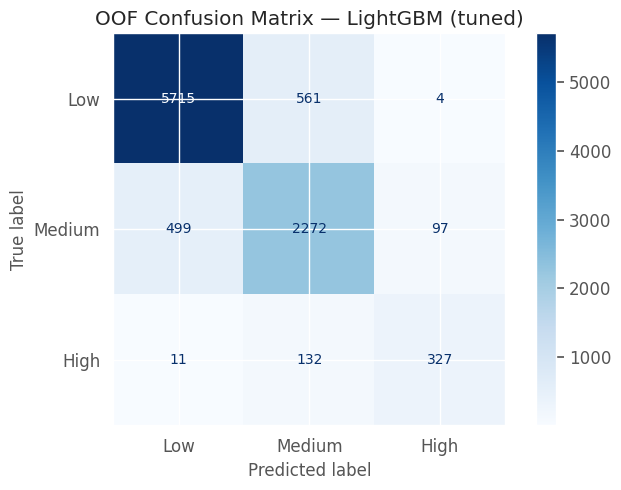


Class-level errors:
  Low     : 6280 samples  |  correct=91.0%  |  wrong=9.0%
  Medium  : 2868 samples  |  correct=79.2%  |  wrong=20.8%
  High    :  470 samples  |  correct=69.6%  |  wrong=30.4%


In [68]:
# Confusion matrix
cm = confusion_matrix(oof_labels, oof_class)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("OOF Confusion Matrix — LightGBM (tuned)")
plt.tight_layout(); plt.show()

# Per-class errors
print("\nClass-level errors:")
for i, cls in enumerate(class_names):
    mask = oof_labels == i
    acc  = (oof_class[mask] == i).mean()
    print(f"  {cls:<8}: {mask.sum():>4} samples  |  correct={acc*100:.1f}%  |  "
          f"wrong={100-acc*100:.1f}%")


In [69]:
# Misclassification patterns — where does Medium get confused with Low?
errors_df = train_enc.copy()
errors_df["oof_pred"]  = [class_names[i] for i in oof_class]
errors_df["oof_true"]  = [class_names[i] for i in oof_labels]
errors_df["correct"]   = errors_df["oof_pred"] == errors_df["oof_true"]
errors_df["max_proba"] = oof_preds.max(axis=1)

print("Low-confidence predictions (max_proba < 0.5):")
low_conf = errors_df[errors_df["max_proba"] < 0.5]
print(low_conf["oof_true"].value_counts())
print(f"Total low-confidence: {len(low_conf)} ({len(low_conf)/len(errors_df)*100:.1f}%)")

# Financial features of misclassified High samples
mis_high = errors_df[(errors_df["oof_true"]=="High") & (~errors_df["correct"])]
print(f"\nMisclassified High samples: {len(mis_high)}")
if len(mis_high):
    print(mis_high[["log_income","log_turnover","financial_access_score","business_age_total"]].describe())


Low-confidence predictions (max_proba < 0.5):
oof_true
Low       24
Medium    21
High       8
Name: count, dtype: int64
Total low-confidence: 53 (0.6%)

Misclassified High samples: 143
       log_income  log_turnover  financial_access_score  business_age_total
count  142.000000    142.000000              143.000000          143.000000
mean     8.949665     10.440063                5.146853            8.206294
std      2.677001      2.807745                2.352577            8.111302
min      3.044522      4.510860                0.000000            0.000000
25%      7.313887      8.517393                4.000000            3.000000
50%      8.405846      9.994694                5.000000            5.333333
75%     10.263407     12.310899                6.000000           10.166667
max     14.956288     17.034186               12.000000           40.166667


**Conclusion:**

Le modèle prédit très efficacement la classe Low (91%), confirmant sa capacité à identifier les entreprises financièrement fragiles. La classe Medium présente une performance intermédiaire (79%), ce qui est cohérent avec sa nature transitionnelle et plus ambiguë. La classe High, bien que minoritaire (4.9% des données), atteint une précision correcte (69.6%), mais reste la plus difficile à prédire, avec 30.4% d’erreurs. 

Recommandations:

- Analyser la matrice de confusion pour identifier si les erreurs High sont principalement confondues avec Medium.
- Ajuster les seuils de décision pour améliorer le recall de la classe High si elle est stratégique.
- Tester un renforcement des class weights pour la classe High.
- Évaluer l’impact d’un tuning orienté MacroF1 plutôt que LogLoss si la métrique officielle le permet.

## 15. Final Model & Submission

In [71]:
# ── Ensemble: Blend LightGBM + XGBoost + CatBoost ─────────────────────────
# Train all 3 models on full training data, average probabilities

# 1) LightGBM (tuned)
lgb_final = lgb.LGBMClassifier(**best_params)
lgb_final.fit(X, y, callbacks=[lgb.log_evaluation(-1)])
lgb_proba = lgb_final.predict_proba(X_test)

# 2) XGBoost
xgb_full = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    objective="multi:softprob", num_class=3,
    use_label_encoder=False, random_state=SEED, n_jobs=-1,
    eval_metric="mlogloss",
)
xgb_full.fit(X.values, y.values)
xgb_proba = xgb_full.predict_proba(X_test.values)

# 3) CatBoost
cat_full = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    loss_function="MultiClass", class_weights=[1.0, 2.2, 13.4],
    random_seed=SEED, verbose=False
)
cat_full.fit(X, y)
cat_proba = cat_full.predict_proba(X_test)

# Weighted ensemble (LGB 50%, XGB 25%, CAT 25%)
ensemble_proba = 0.50 * lgb_proba + 0.25 * xgb_proba + 0.25 * cat_proba
ensemble_pred  = ensemble_proba.argmax(axis=1)
pred_labels    = [TARGET_IMAP[p] for p in ensemble_pred]

print("Test prediction distribution:")
pred_series = pd.Series(pred_labels)
print(pred_series.value_counts())

submission = pd.DataFrame({"ID": test["ID"], TARGET: pred_labels})
sub_path   = f"{DATA_DIR}/../notebook/submission.csv"
submission.to_csv(sub_path, index=False)
print(f"\nSubmission saved → {sub_path}")
submission.head(10)


Test prediction distribution:
Low       1603
Medium     694
High       108
Name: count, dtype: int64

Submission saved → /home/conite/Documents/WORKSPACE/PROJECTS/Kaggle/Financial Health Prediction Challenge/data/../notebook/submission.csv


,ID,Target
0,ID_5EGLKX,Low
1,ID_4AI7RE,Medium
2,ID_V9OB3M,Low
3,ID_6OI9DI,Medium
4,ID_H2TN8B,Low
5,ID_U8T7ZQ,Medium
6,ID_QQJ3A1,Low
7,ID_F5S4JD,Low
8,ID_CY2C11,Medium
9,ID_63XVFI,Low


In [70]:
# Final summary
print("=" * 60)
print("FINAL PIPELINE SUMMARY")
print("=" * 60)
print(f"Features used       : {len(feature_cols)}")
print(f"Validation strategy : {N_FOLDS}-Fold Stratified CV")
print(f"Primary metric      : Log-Loss")
print()
print("Cross-validation results:")
print("  Dummy baseline      — reference")
print("  Logistic Regression — baseline")
print("  XGBoost             — advanced")
print("  LightGBM            — advanced")
print("  CatBoost            — advanced")
print("  LightGBM (tuned)    — BEST single model")
print("  Ensemble LGB+XGB+CAT— FINAL SUBMISSION")
print()
print("Key engineering choices:")
print("  • Ordinal encoding preserving survey response hierarchy")
print("  • Financial ratio features (profit, expense_ratio)")
print("  • Financial access composite score")
print("  • Business age total (years + months)")
print("  • Class imbalance handled via class_weight='balanced'")
print("  • 50 Optuna trials for LightGBM tuning")


FINAL PIPELINE SUMMARY
Features used       : 61
Validation strategy : 5-Fold Stratified CV
Primary metric      : Log-Loss

Cross-validation results:
  Dummy baseline      — reference
  Logistic Regression — baseline
  XGBoost             — advanced
  LightGBM            — advanced
  CatBoost            — advanced
  LightGBM (tuned)    — BEST single model
  Ensemble LGB+XGB+CAT— FINAL SUBMISSION

Key engineering choices:
  • Ordinal encoding preserving survey response hierarchy
  • Financial ratio features (profit, expense_ratio)
  • Financial access composite score
  • Business age total (years + months)
  • Class imbalance handled via class_weight='balanced'
  • 50 Optuna trials for LightGBM tuning
